In [1]:
from dataclasses import dataclass
from enum import StrEnum
from datetime import datetime, timedelta, date
import polars as pl
from collections import defaultdict, Counter
from typing import Tuple
from common.constants.column_types import (
    CPZP_SCHEMA,
    OZP_SCHEMA,
    POHLAVI_CPZP,
    TYP_UDALOSTI,
)
from common.constants.column_names import SHARED_COLUMNS, OZP_COLUMNS, CPZP_COLUMNS
import pickle
from common.constants.objects import (
    Person,
    Gender,
    AgeCohort,
    Prescription,
    PrescriptionType,
)
import matplotlib.pyplot as plt
import numpy as np
import os
from common.utils import (
    draw_chart,
    filter_by_date_range,
)
from bisect import bisect_left, bisect_right
import random

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(60)

pl.Config.set_tbl_rows(-1)


ZACATEK_POJISTENI = date(2015, 1, 1)
KONEC_POJISTENI = date(2023, 12, 31)


class AgeCohort(StrEnum):
    _12_15 = "12-15"
    _16_29 = "16-29"
    _30_49 = "30-49"
    _50_59 = "50-59"
    IRRELEVANT = "irrelevant"


def calculate_age_cohort(person: Person) -> AgeCohort:
    YEAR_FOR_AGE_CALCULATION = 2021

    age = YEAR_FOR_AGE_CALCULATION - person.born_at.year
    if age >= 12 and age <= 15:
        return AgeCohort._12_15
    elif age >= 16 and age <= 29:
        return AgeCohort._16_29
    elif age >= 30 and age <= 49:
        return AgeCohort._30_49
    elif age >= 50 and age <= 59:
        return AgeCohort._50_59
    else:
        return AgeCohort.IRRELEVANT


def is_injection(pr: Prescription) -> bool:
    return pr.lekova_forma_zkr and (pr.lekova_forma_zkr.startswith("INJ"))


def create_prednison_enum(step: int = 25, max_value: int = 5000):
    values = {"ZERO": "zero", f"MORE_THAN_{max_value}": f"more_than_{max_value}"}

    for start in range(0, max_value, step):
        end = start + step
        name = f"BETWEEN_{start}_AND_{end}"
        values[name] = name.lower()

    return StrEnum("PREDNISON_EQUIV_CATEGORY", values)


PREDNISON_EQUIV_CATEGORY = create_prednison_enum()


def from_prednison_equiv(prednison_equiv: float) -> PREDNISON_EQUIV_CATEGORY:
    if prednison_equiv == 0:
        return PREDNISON_EQUIV_CATEGORY.ZERO

    step = 25
    max_value = 5000

    if prednison_equiv >= max_value:
        return PREDNISON_EQUIV_CATEGORY[f"MORE_THAN_{max_value}"]

    start = int((prednison_equiv // step) * step)
    end = start + step
    name = f"BETWEEN_{start}_AND_{end}"
    return PREDNISON_EQUIV_CATEGORY[name]


def find_matching_person(
    vax_person: Person,
    pe_range: PREDNISON_EQUIV_CATEGORY,
    vax_date: datetime,
    novax_map: dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
) -> str:
    ac = calculate_age_cohort(vax_person)
    gender = vax_person.gender
    novax_matched_ids = novax_map[vax_date][pe_range][ac][gender]
    max_int = len(novax_matched_ids)
    random_index = random.randint(0, max_int - 1)
    return novax_matched_ids[random_index]


def sum_after_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate and pr.date < ddate + timedelta(days=365))
    )


def sum_before_date_pe_for_person(person: Person, ddate: datetime) -> float:
    return sum(
        pr.prednison_equiv
        for pr in person.prescriptions
        if (not is_injection(pr))
        and (pr.date > ddate - timedelta(days=365) and pr.date < ddate)
    )

In [2]:
POJISTOVNA = "cpzp"
with open(f"./DATACON_data/{POJISTOVNA}_persons.pkl", "rb") as f:
    persons: list[Person] = pickle.load(f)

In [3]:
novax_persons_to_analyse = [
    p
    for p in persons
    if not p.vaccines
    and p.died_at is None
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

person_map = {p.id: p for p in persons}
vax_people = [
    p
    for p in persons
    if p.vaccines
    and p.died_at is None  # klidně do roku 2023
    and (
        p.zahajeni_pojisteni < ZACATEK_POJISTENI
        and p.ukonceni_pojisteni > KONEC_POJISTENI
    )
]

anchor_dates = [
    (datetime(2021, 1, 1) + timedelta(days=i)).date()
    for i in range((datetime(2022, 2, 28) - datetime(2021, 1, 1)).days + 1)
]

vax_dates_distribution: dict[AgeCohort, dict[datetime, float]] = defaultdict(
    lambda: defaultdict(float)
)

for vax_person in vax_people:
    ac = calculate_age_cohort(vax_person)
    vax_date = vax_person.vaccines[0].date
    vax_dates_distribution[ac][vax_date] += 1


In [5]:
# for vax_person in vax_people:
#     first_vax = vax_person.vaccines[0]
#     vax_person.sum_of_pe_before_vax = sum_before_date_pe_for_person(
#         vax_person, first_vax.date
#     )
#     vax_person.sum_of_pe_after_vax = sum_after_date_pe_for_person(
#         vax_person, first_vax.date
#     )

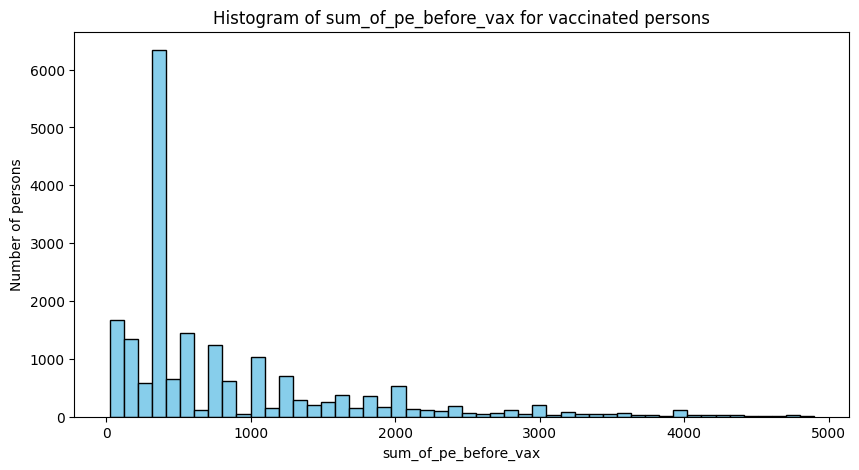

In [ ]:
sum_of_pe_before_vax_values = [
    p.sum_of_pe_before_vax
    for p in vax_people
    if p.sum_of_pe_before_vax < 5000 and p.sum_of_pe_before_vax > 0
]

plt.figure(figsize=(10, 5))
plt.hist(sum_of_pe_before_vax_values, bins=50, color="skyblue", edgecolor="black")
plt.title("Histogram of sum_of_pe_before_vax for vaccinated persons")
plt.xlabel("sum_of_pe_before_vax")
plt.ylabel("Number of persons")
plt.show()

# 0, 1-500, 500-5000, kyblíčková analýza
# dát pryč 5000+


In [6]:
def compute_prednison_windows(
    people: list[Person], vax_anchor_dates: list[datetime]
) -> dict[datetime, dict[str | int, float]]:
    # Prepare output structure
    result: dict[
        datetime,
        dict[PREDNISON_EQUIV_CATEGORY, dict[AgeCohort, dict[Gender, set[int]]]],
    ] = {ad: {} for ad in vax_anchor_dates}

    completed_persons = 0
    len_of_persons_to_analyse = len(people)
    for person in people:
        completed_persons += 1
        print(
            f"Processing person {completed_persons}/{len_of_persons_to_analyse}",
            end="\r",
        )

        # person_prescriptions = sorted(person.prescriptions, key=lambda pr: pr.date)
        person_prescriptions = [
            pr
            for pr in sorted(person.prescriptions, key=lambda pr: pr.date)
            if not (is_injection(pr))
        ]
        if not person_prescriptions:
            # no prescriptions → all anchor dates = 0
            for anchor in vax_anchor_dates:
                # result[ad][person.id] = 0.0
                pe_range = from_prednison_equiv(0)
                if pe_range not in result[anchor]:
                    result[anchor][pe_range] = {}

                ac = calculate_age_cohort(person)
                if ac not in result[anchor][pe_range]:
                    result[anchor][pe_range][ac] = {}

                if person.gender not in result[anchor][pe_range][ac]:
                    result[anchor][pe_range][ac][person.gender] = set()

                result[anchor][pe_range][ac][person.gender].add(person.id)
            continue

        # For accumulation:
        # Each anchor date holds its sum of prednison for this person
        per_person_map: dict[datetime, float] = {ad: 0.0 for ad in vax_anchor_dates}

        # 3) For each prescription, add its value to all anchor dates
        #    within pr.date → pr.date + 365 days
        for pr in person_prescriptions:
            start = pr.date
            end = pr.date + timedelta(days=365)

            # indices of anchor dates inside [start, end]
            i = bisect_left(vax_anchor_dates, start)
            j = bisect_right(vax_anchor_dates, end)

            # Add prednison_equiv to each matching anchor date
            for idx in range(i, j):
                anchor = vax_anchor_dates[idx]
                per_person_map[anchor] += pr.prednison_equiv

        # Store per-person results
        for anchor, value in per_person_map.items():
            # result[anchor][person.id] = value
            pe_range = from_prednison_equiv(value)
            if pe_range not in result[anchor]:
                result[anchor][pe_range] = {}

            ac = calculate_age_cohort(person)
            if ac not in result[anchor][pe_range]:
                result[anchor][pe_range][ac] = {}

            if person.gender not in result[anchor][pe_range][ac]:
                result[anchor][pe_range][ac][person.gender] = set()

            result[anchor][pe_range][ac][person.gender].add(person.id)

    for anchor, ranges in result.items():
        for pe_range, acs in ranges.items():
            for ac, genders in acs.items():
                for gender, idset in genders.items():
                    genders[gender] = list(idset)

    return result


In [7]:
pe_map = compute_prednison_windows(novax_persons_to_analyse, anchor_dates)

In [ ]:
def compute_vax_vs_novax_sums(people):
    vax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    vax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_before_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    novax_after_pe_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(
        lambda: defaultdict(float)
    )
    for person in people:
        first_vax = person.vaccines[0]
        vax_person_before_pe = sum_before_date_pe_for_person(person, first_vax.date)
        if vax_person_before_pe > 5000:
            continue
        vax_person_after_pe = sum_after_date_pe_for_person(person, first_vax.date)

        pe_range = from_prednison_equiv(vax_person_before_pe)
        try:
            matched_id = find_matching_person(person, pe_range, first_vax.date, pe_map)
        except Exception:
            continue

        novax_person_before_pe = sum_before_date_pe_for_person(
            person_map[matched_id], first_vax.date
        )
        novax_person_after_pe = sum_after_date_pe_for_person(
            person_map[matched_id], first_vax.date
        )

        ac = calculate_age_cohort(person)
        vax_before_pe_map[ac][first_vax.date] += vax_person_before_pe
        vax_after_pe_map[ac][first_vax.date] += vax_person_after_pe
        novax_before_pe_map[ac][first_vax.date] += novax_person_before_pe
        novax_after_pe_map[ac][first_vax.date] += novax_person_after_pe

    return vax_before_pe_map, vax_after_pe_map, novax_before_pe_map, novax_after_pe_map

In [12]:
vax_before_pe_map, vax_after_pe_map, novax_before_pe_map, novax_after_pe_map = (
    compute_vax_vs_novax_sums(vax_people)
)

In [ ]:
result_map: dict[AgeCohort, dict[datetime, float]] = defaultdict(dict)

for cohort in (
    set(vax_before_pe_map.keys())
    | set(vax_after_pe_map.keys())
    | set(novax_before_pe_map.keys())
    | set(novax_after_pe_map.keys())
):
    # All dates inside this cohort across all four dicts
    all_dates = (
        set(vax_before_pe_map[cohort].keys())
        | set(vax_after_pe_map[cohort].keys())
        | set(novax_before_pe_map[cohort].keys())
        | set(novax_after_pe_map[cohort].keys())
    )

    result_map[cohort] = {}

    for dt in all_dates:
        vax_before = vax_before_pe_map[cohort].get(dt, 0.0)
        vax_after = vax_after_pe_map[cohort].get(dt, 0.0)
        novax_before = novax_before_pe_map[cohort].get(dt, 0.0)
        novax_after = novax_after_pe_map[cohort].get(dt, 0.0)

        # avoid division by zero
        if vax_after != 0 and novax_after != 0:
            res = (vax_before / vax_after) - (novax_before / novax_after)
            # if abs(res) < 1:
            result_map[cohort][dt] = res

# 0, 1-100, 100-1000, 1000-5000, 5000+
# u 0 mít vax_after/novax_after
# možná udělat (vax_after-vax_before)/(novax_after-novax_before)

In [ ]:
from collections import defaultdict
import numpy as np
from typing import Dict, List, Tuple
from datetime import datetime

# Type alias for clarity
EffectMap = Dict[AgeCohort, Dict[datetime, float]]


def run_matching_analysis(
    people,
    num_runs: int = 100,
    ci_level: float = 0.95,
) -> Tuple[EffectMap, EffectMap]:
    """
    Run the matching analysis N times, collect effect values,
    and return:
        - mean_effect_map
        - ci_map (lower, upper)
    """

    # stores: cohort -> date -> list of effect values
    effects: Dict[AgeCohort, Dict[datetime, List[float]]] = defaultdict(
        lambda: defaultdict(list)
    )

    for _ in range(num_runs):
        # RUN YOUR ORIGINAL ANALYSIS
        vax_before, vax_after, novax_before, novax_after = compute_vax_vs_novax_sums(
            people
        )

        # TRANSFORM INTO EFFECT VALUES
        result_map = compute_effect_values(
            vax_before, vax_after, novax_before, novax_after
        )

        # STORE
        for cohort, date_map in result_map.items():
            for dt, value in date_map.items():
                effects[cohort][dt].append(value)

        print(f"Processed {_} runs")

    # COMPUTE STATS
    mean_map, ci_map = compute_statistics(effects, ci_level)

    return mean_map, ci_map


def compute_effect_values(
    vax_before_pe_map,
    vax_after_pe_map,
    novax_before_pe_map,
    novax_after_pe_map,
) -> EffectMap:
    result_map: EffectMap = defaultdict(dict)

    cohorts = (
        set(vax_before_pe_map.keys())
        | set(vax_after_pe_map.keys())
        | set(novax_before_pe_map.keys())
        | set(novax_after_pe_map.keys())
    )

    for cohort in cohorts:
        all_dates = (
            set(vax_before_pe_map[cohort].keys())
            | set(vax_after_pe_map[cohort].keys())
            | set(novax_before_pe_map[cohort].keys())
            | set(novax_after_pe_map[cohort].keys())
        )

        for dt in all_dates:
            vax_before = vax_before_pe_map[cohort].get(dt, 0.0)
            vax_after = vax_after_pe_map[cohort].get(dt, 0.0)
            novax_before = novax_before_pe_map[cohort].get(dt, 0.0)
            novax_after = novax_after_pe_map[cohort].get(dt, 0.0)

            if vax_after != 0 and novax_after != 0:
                res = (vax_before / vax_after) - (novax_before / novax_after)
                result_map[cohort][dt] = res

    return result_map


def compute_statistics(
    effects: Dict[AgeCohort, Dict[datetime, List[float]]], ci_level: float
):
    mean_map: EffectMap = defaultdict(dict)
    ci_map: Dict[AgeCohort, Dict[datetime, Tuple[float, float]]] = defaultdict(dict)

    alpha = 1 - ci_level

    for cohort, date_map in effects.items():
        for dt, values in date_map.items():
            arr = np.array(values)

            mean = arr.mean()
            lower = np.percentile(arr, alpha / 2 * 100)
            upper = np.percentile(arr, (1 - alpha / 2) * 100)

            mean_map[cohort][dt] = mean
            ci_map[cohort][dt] = (lower, upper)

    return mean_map, ci_map


mean_map, ci_map = run_matching_analysis(vax_people, num_runs=100)

for cohort, date_map in mean_map.items():
    sorted_dates = sorted(date_map.keys())
    y_mean = [mean_map[cohort][d] for d in sorted_dates]
    y_lower = [ci_map[cohort][d][0] for d in sorted_dates]
    y_upper = [ci_map[cohort][d][1] for d in sorted_dates]

    fig, ax = plt.subplots(figsize=(10, 5))

    # plot mean
    ax.plot(sorted_dates, y_mean, label="Effect")

    # fill CI
    ax.fill_between(sorted_dates, y_lower, y_upper, alpha=0.2, label="CI")

    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(f"Effect with CI — Cohort {cohort}")
    ax.legend()
    fig.autofmt_xdate()
    fig.tight_layout()
    # fig.savefig(f"runs/effect_over_time_{cohort}.png")
    plt.show()
    plt.close(fig)


Processed 0 runs
Processed 1 runs
Processed 2 runs
Processed 3 runs
Processed 4 runs
Processed 5 runs
Processed 6 runs
Processed 7 runs
Processed 8 runs
Processed 9 runs
Processed 10 runs
Processed 11 runs
Processed 12 runs
Processed 13 runs
Processed 14 runs
Processed 15 runs
Processed 16 runs
Processed 17 runs
Processed 18 runs
Processed 19 runs
Processed 20 runs
Processed 21 runs
Processed 22 runs
Processed 23 runs
Processed 24 runs
Processed 25 runs
Processed 26 runs
Processed 27 runs
Processed 28 runs
Processed 29 runs
Processed 30 runs
Processed 31 runs


In [16]:
for cohort, date_map in result_map.items():
    sorted_dates = sorted(date_map.keys())
    sorted_values = [date_map[d] for d in sorted_dates]

    vax_counts = [vax_dates_distribution[cohort].get(d, 0) for d in sorted_dates]

    fig, ax_left = plt.subplots(figsize=(10, 5))

    ax_left.plot(sorted_dates, sorted_values, label="Effect", color="blue")
    ax_left.axhline(0, color="black", linewidth=1)
    ax_left.set_xlabel("Date")
    ax_left.set_ylabel("Effect Value")
    ax_left.set_title(f"Effect Over Time — Cohort: {cohort}")

    ax_right = ax_left.twinx()
    ax_right.plot(
        sorted_dates,
        vax_counts,
        label="Vaccinated",
        linestyle="--",
        color="orange",  # ← your new color
    )
    ax_right.set_ylabel("Vaccinated Count")

    fig.autofmt_xdate()
    fig.tight_layout()
    fig.savefig(f"runs/4/effect_over_time_{cohort}.png")
    plt.close(fig)


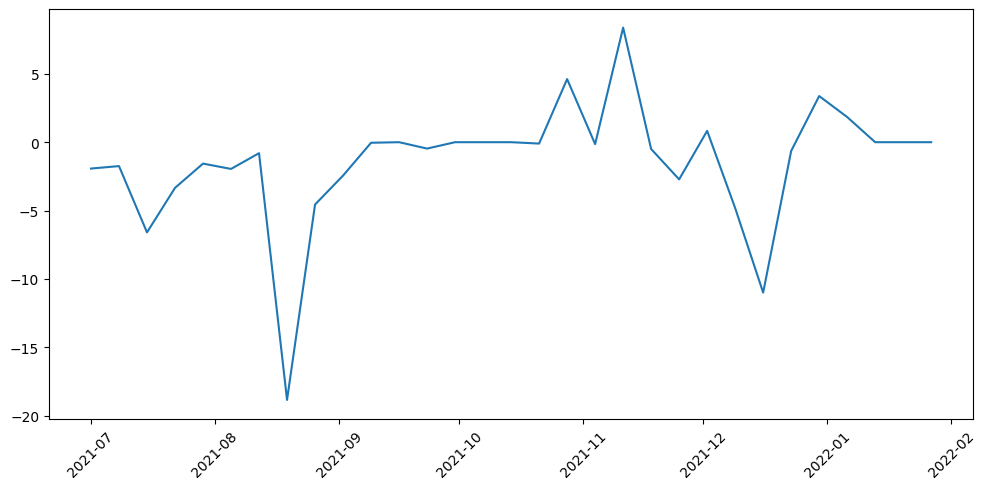

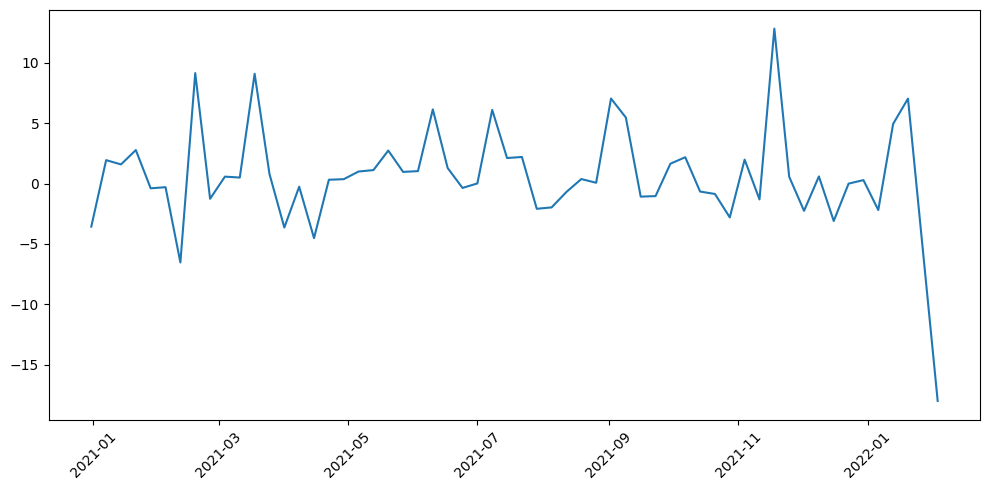

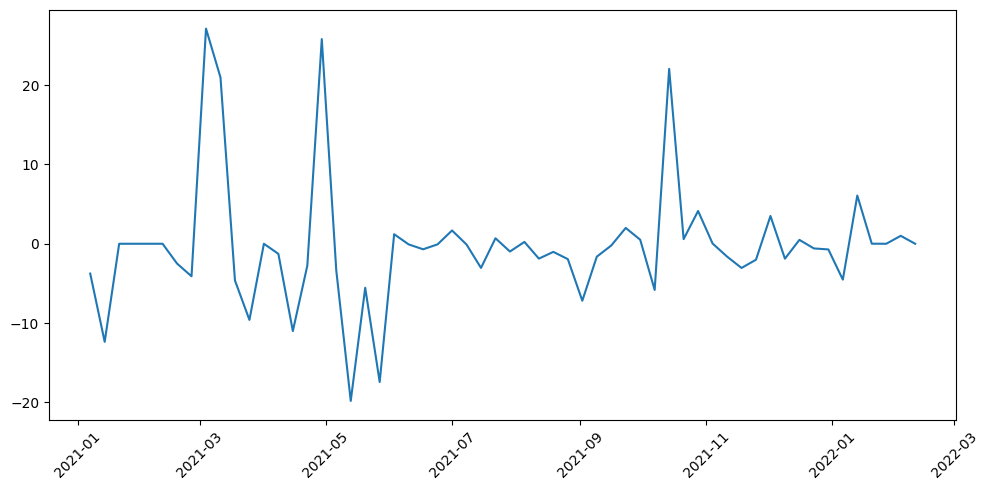

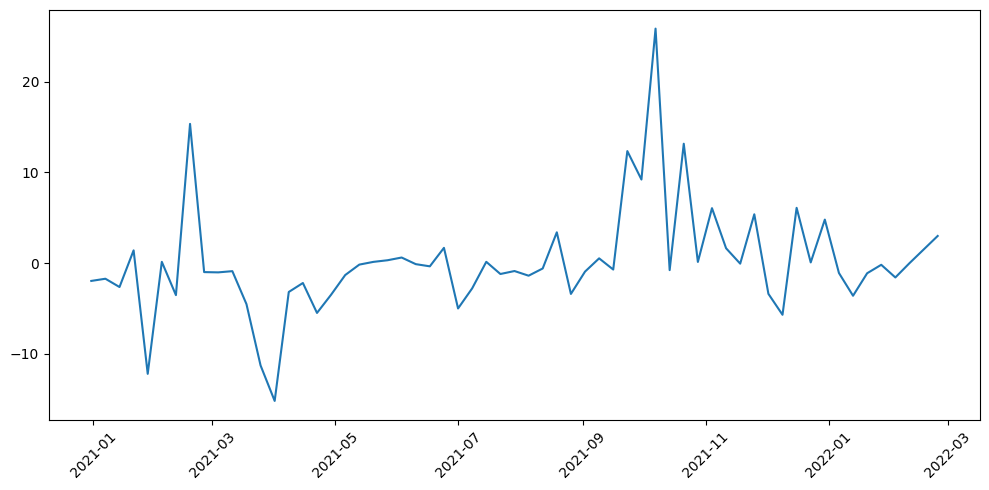

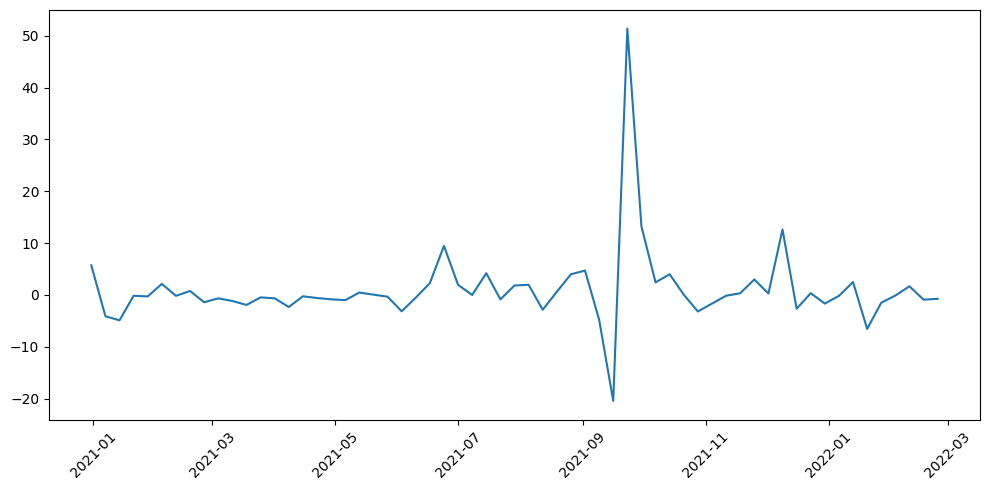

In [17]:
from datetime import timedelta


def floor_date(dt, days):
    epoch = datetime(1970, 1, 1).date()
    delta = (dt - epoch).days
    bucket_start = delta // days * days
    return epoch + timedelta(days=bucket_start)


for cohort, date_map in result_map.items():
    aggregated = {}
    for dt, value in date_map.items():
        bucket = floor_date(dt, 7)  # or 14
        aggregated.setdefault(bucket, 0)
        aggregated[bucket] += value  # or average later

    sorted_dates = sorted(aggregated.keys())
    sorted_values = [aggregated[d] for d in sorted_dates]

    plt.figure(figsize=(10, 5))
    plt.plot(sorted_dates, sorted_values)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
